In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)

from cv_utils import *
from pitch_segmentation import *

import albumentations
from torchvision import *

### Load data

[[2560    0]
 [2560 1440]
 [   0 1440]
 [   0    0]]


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

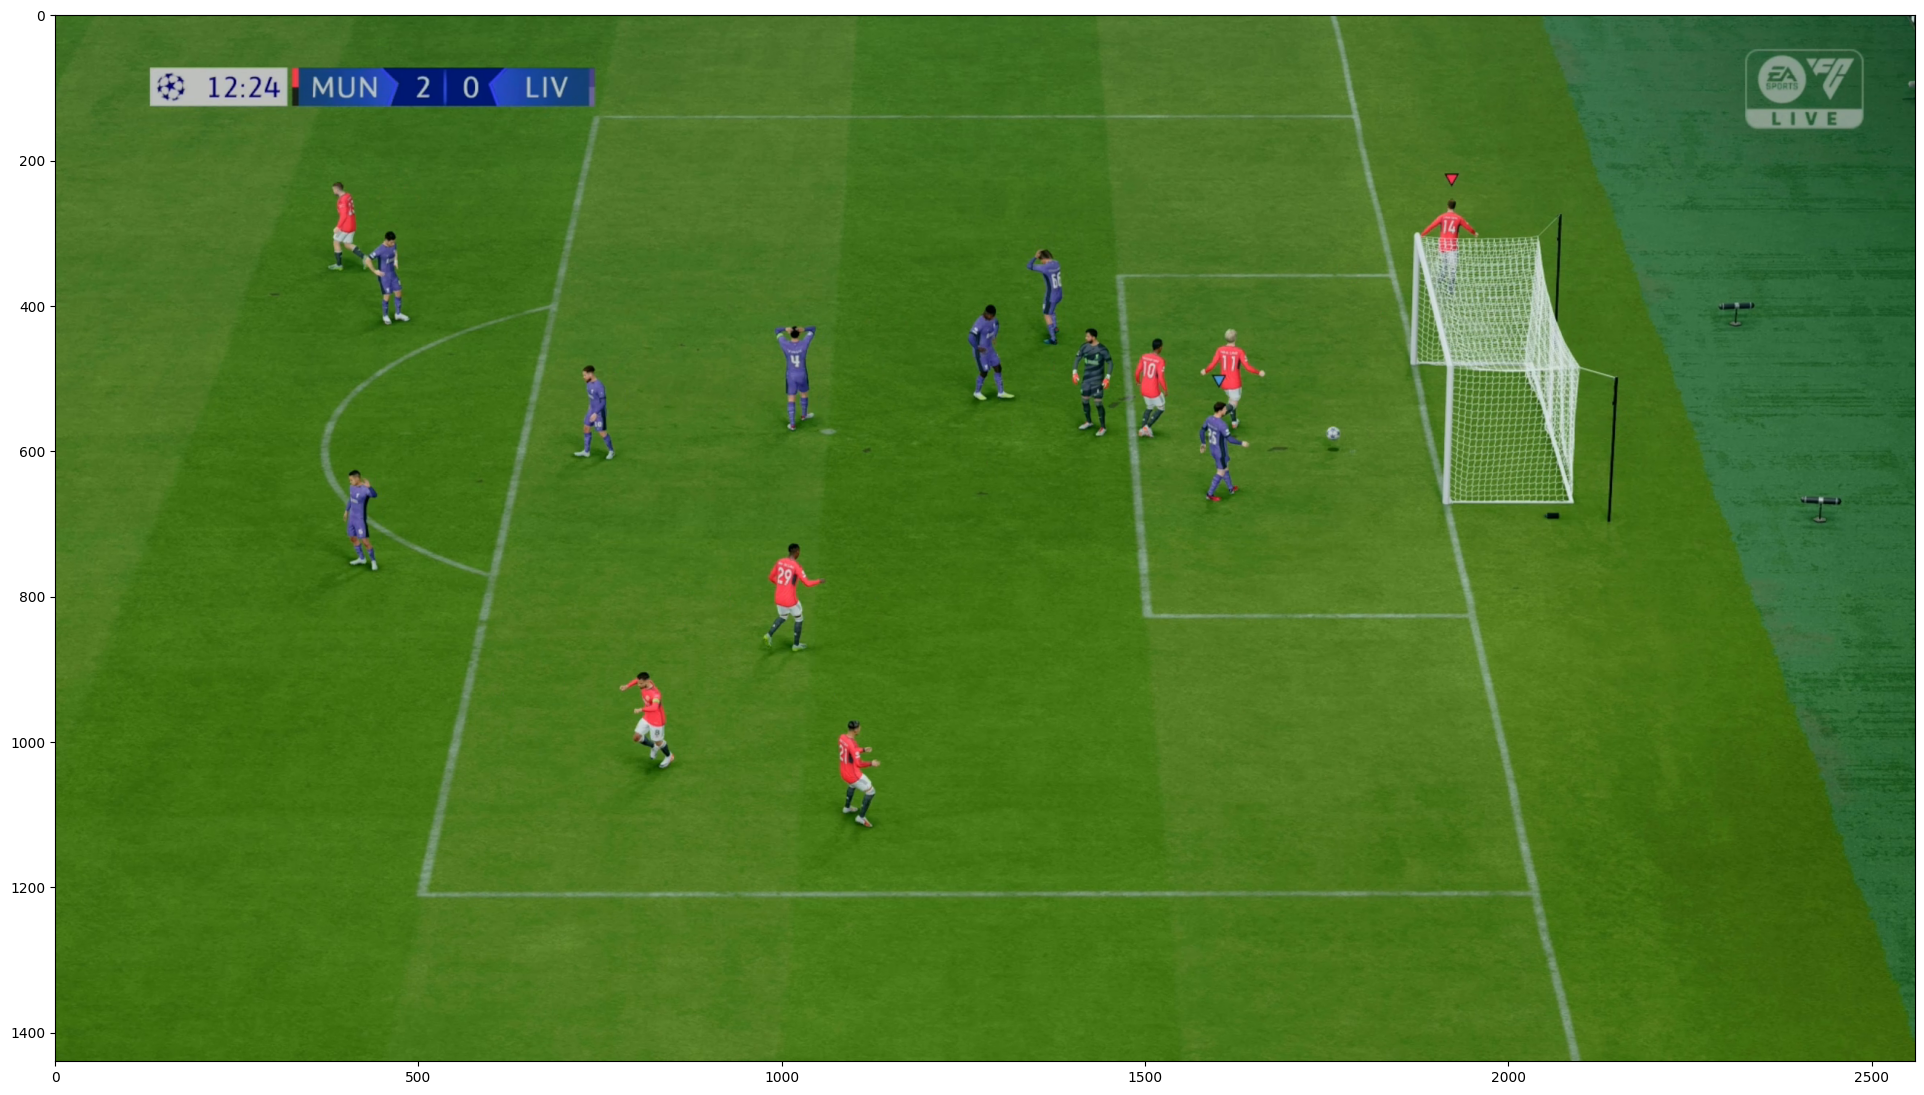

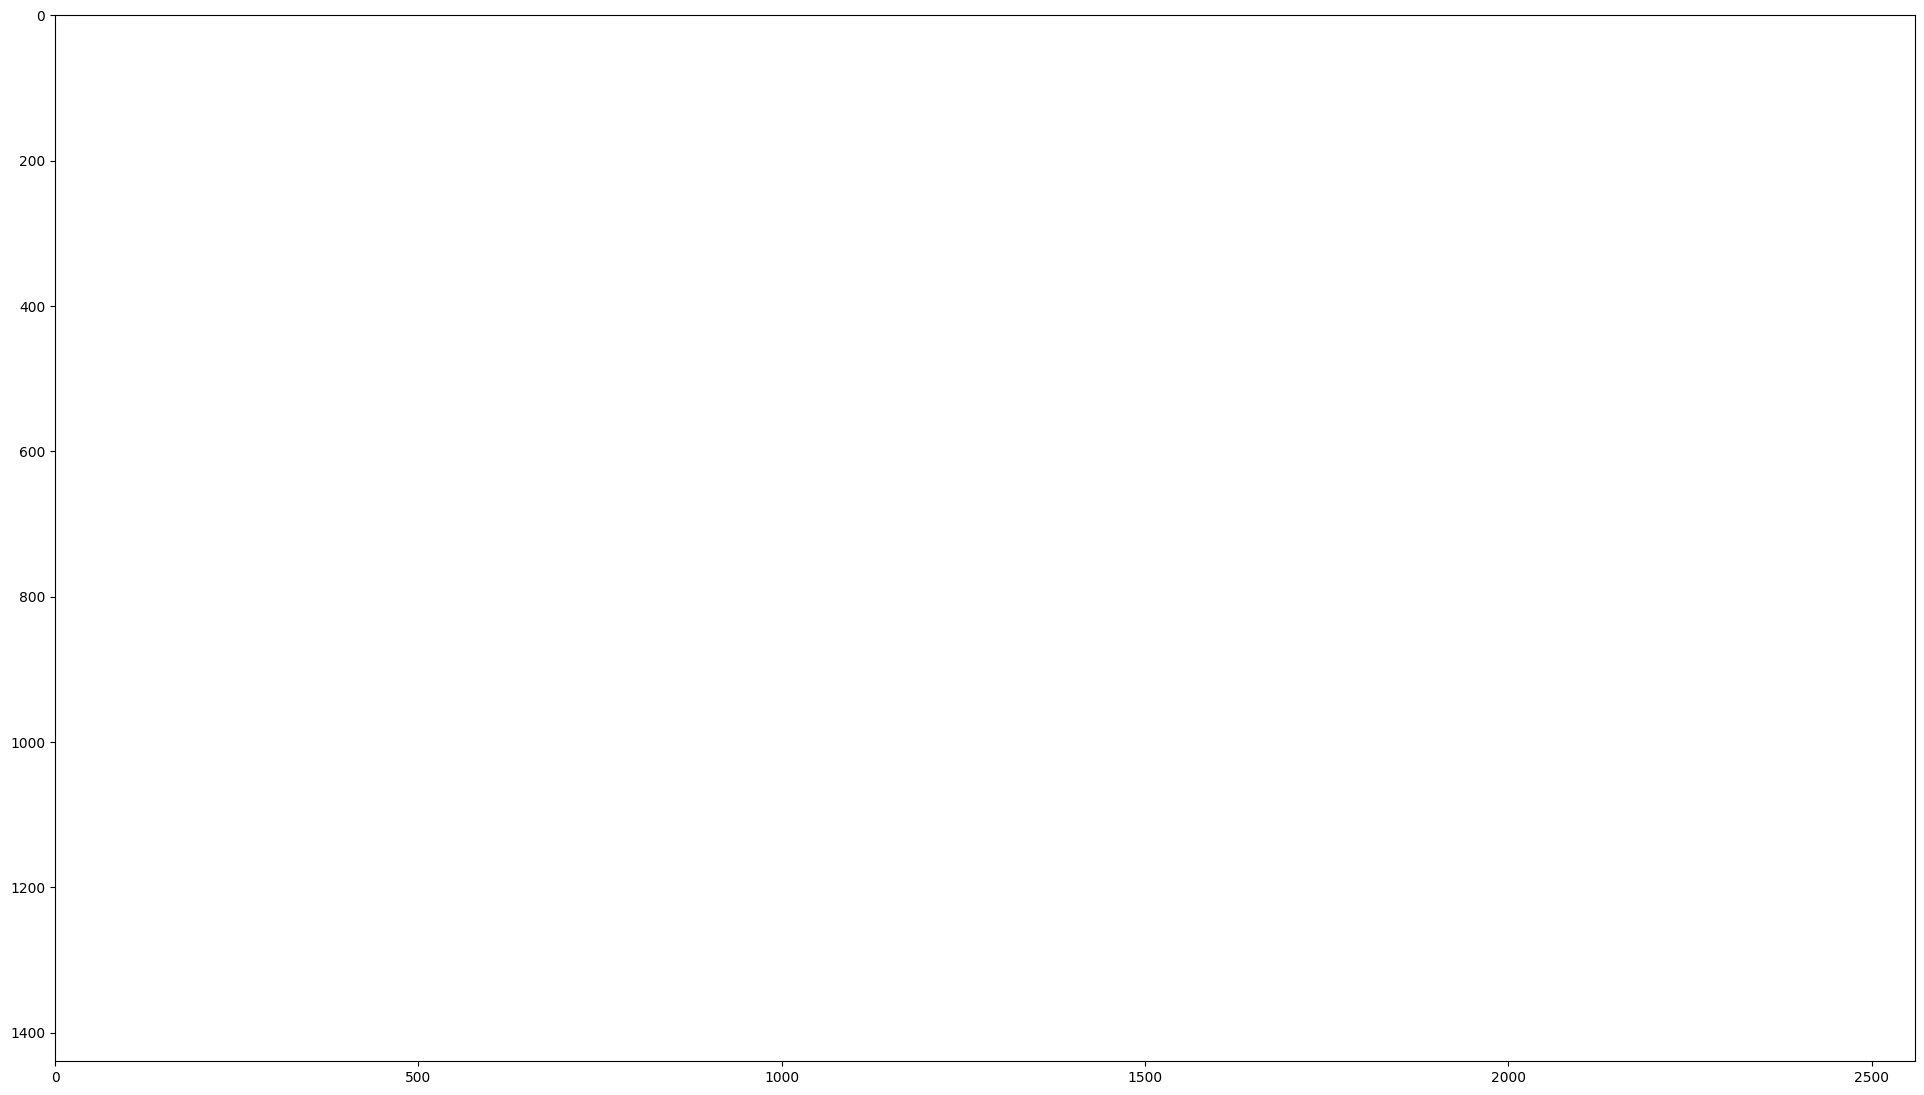

In [2]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
merge_dest_path = os.path.join(data_path, 'coco_datasets/real_synth_train_pitch')

image_folder = os.path.join(merge_dest_path, "images")
annotation_file = os.path.join(merge_dest_path, "annotations", "instances_default.json")

with open(annotation_file, 'r') as f:
    annotations = json.load(f)

image_id = 517
image_name = [image_info["file_name"] for image_info in annotations['images']
                                        if image_info['id'] == image_id][0]
annotation_list = [annotation 
                    for annotation in annotations['annotations']
                    if annotation['image_id'] == image_id][0]

image_path = os.path.join(image_folder, image_name)
image = cv2.cvtColor(cv2.imread(image_path, 
                                        cv2.IMREAD_UNCHANGED), cv2.COLOR_BGR2RGB)
plt.figure()
plt.imshow(image)

annotation = np.array(annotation_list['segmentation'][0], 
                                dtype=np.int32).reshape((-1, 2))
print(annotation)
mask = np.zeros(image.shape[:2], dtype=np.uint8)
cv2.fillPoly(mask, [annotation], color=255)
plt.figure()
plt.imshow(mask, cmap='gray', vmin=0, vmax=255)
mask

In [3]:
merge = False
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
coco_dataset_path_1 = os.path.join(data_path, 'coco_datasets/real_train_pitch')
coco_dataset_path_2 = os.path.join(data_path, 'coco_datasets/synth_train_pitch')
if merge:
    dest_path=os.path.join(data_path, 'coco_datasets')
    merge_dest_path = merge_coco_dataset(coco_dataset_path_1, coco_dataset_path_2,
                    dest_path=os.path.join(data_path, 'coco_datasets'))
else:
    merge_dest_path = os.path.join(data_path, 'coco_datasets/real_synth_train_pitch')

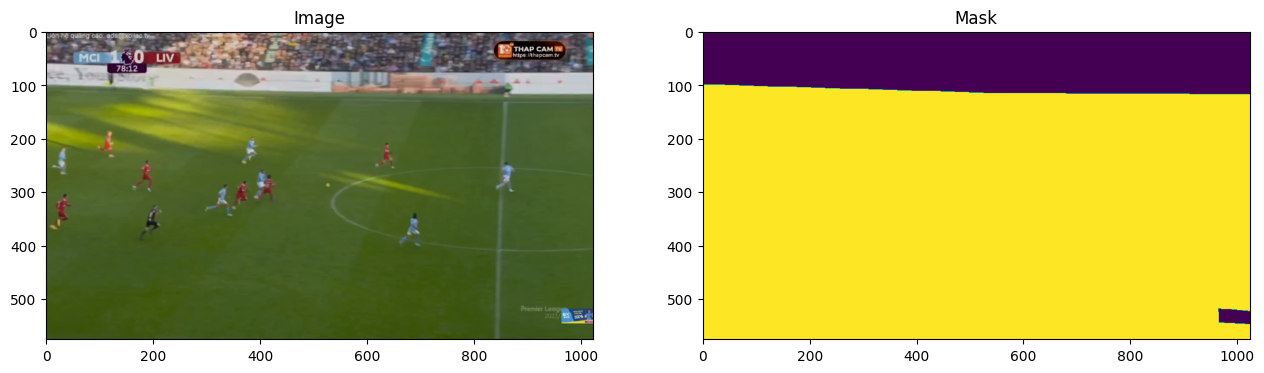

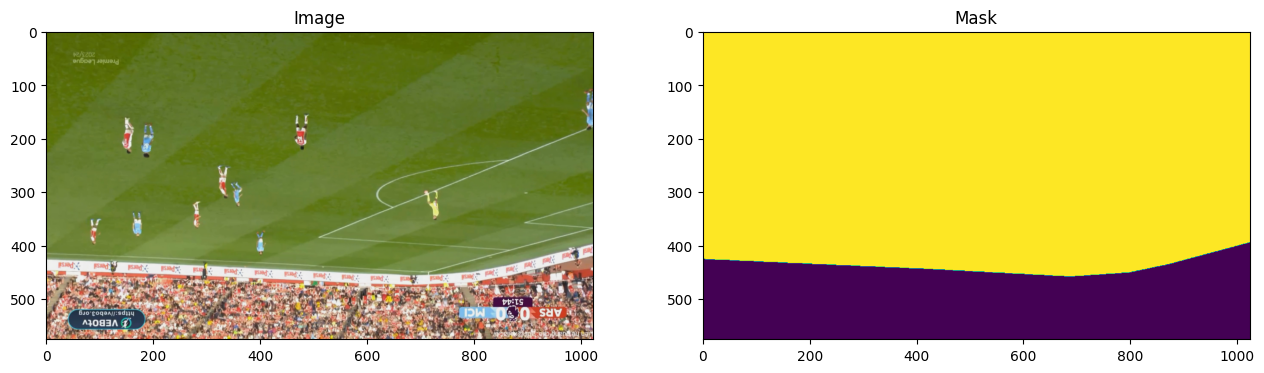

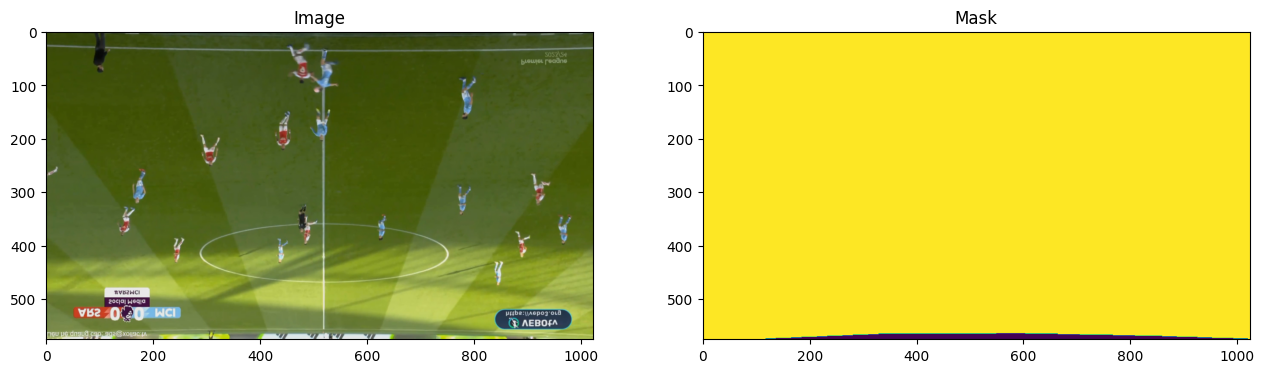

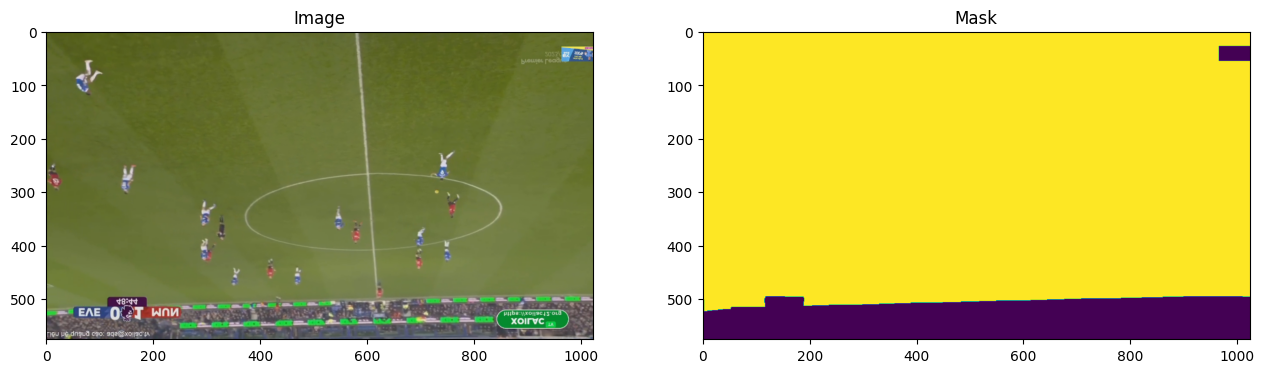

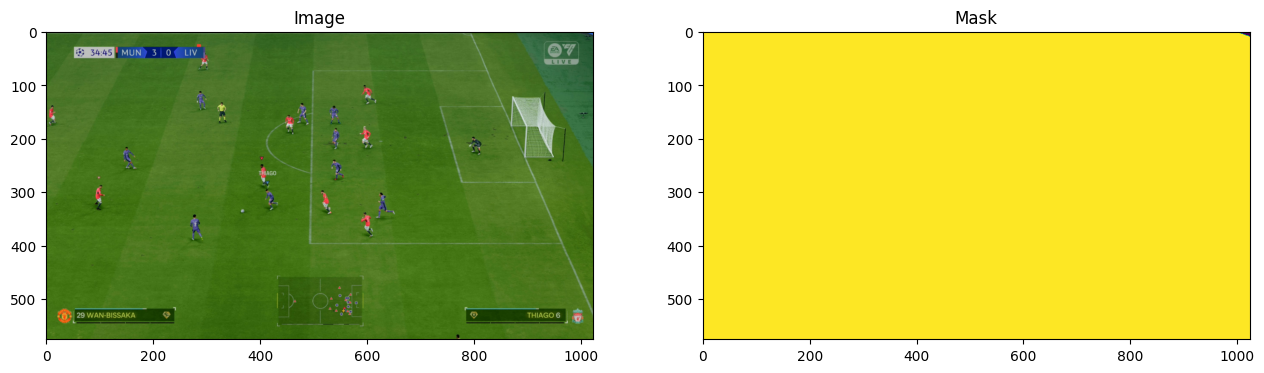

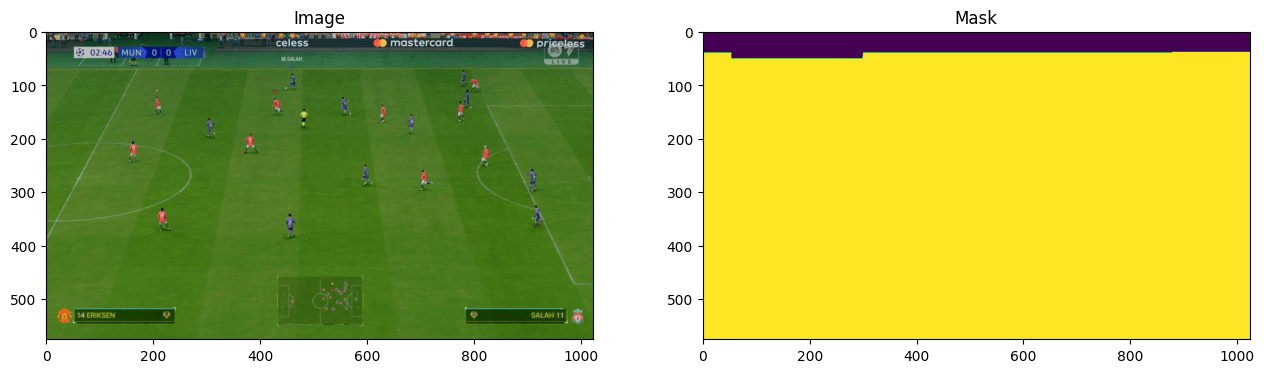

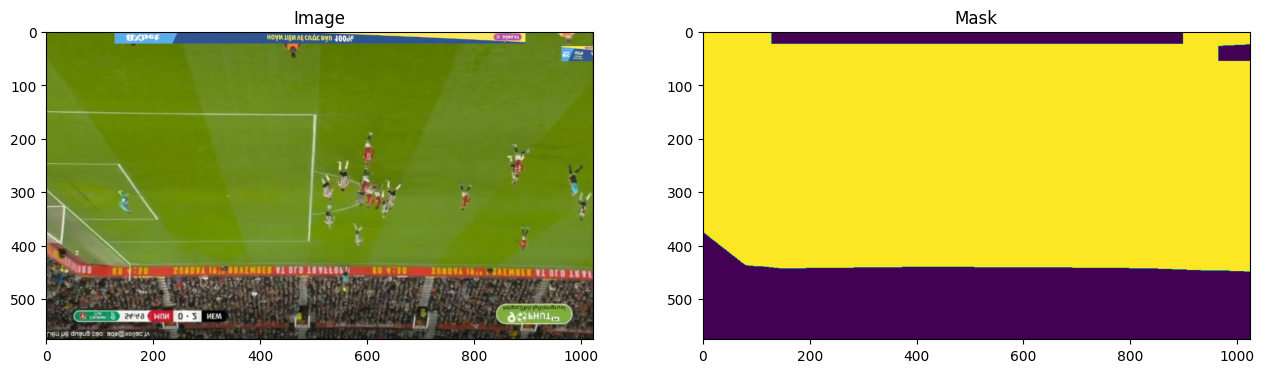

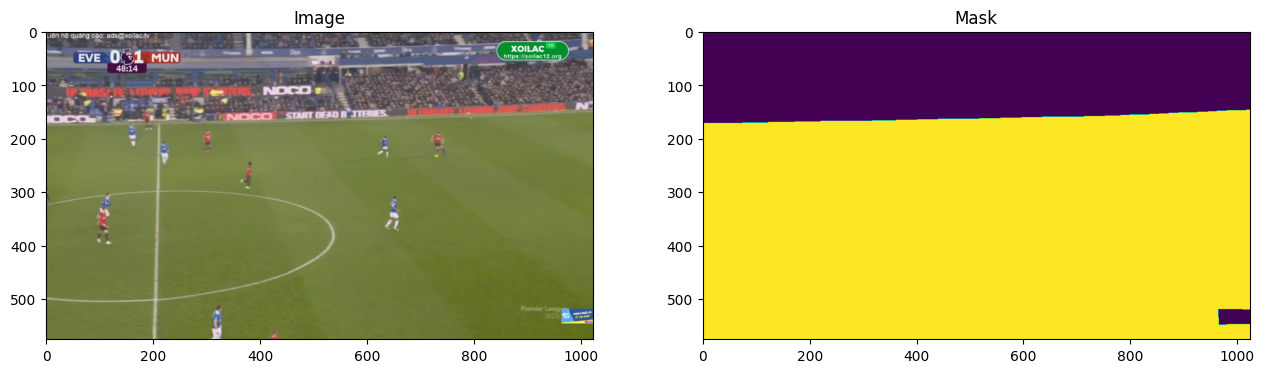

In [4]:
image_folder = os.path.join(merge_dest_path, "images")
annotation_file = os.path.join(merge_dest_path, "annotations", "instances_default.json")

transform = albumentations.Compose([
        albumentations.Resize(576, 1024),
        albumentations.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
        albumentations.HorizontalFlip(p=0.5),
        albumentations.VerticalFlip(p=0.5)
        ])

dataset = PitchDataset(image_folder=image_folder, annotation_file=annotation_file
                       , transform=transform)
data_loader = DataLoader(dataset, batch_size=12, shuffle=True)
images, masks = next(iter(data_loader))

for i in range(8):
    plt.figure()
    plt.subplot(1, 3, 1)
    plt.imshow(images[i].permute(1, 2, 0).numpy())
    plt.title("Image")
    plt.subplot(1, 3, 2)
    plt.imshow(masks[i].permute(1, 2, 0).numpy().astype(np.int32)*255)
    plt.title("Mask")


### Train model

cuda


100%|██████████████████████████████████████████████████████████████████████████████████| 52/52 [06:58<00:00,  8.04s/it]


Epoch [1/10], Loss: -15.54121477672687


100%|██████████████████████████████████████████████████████████████████████████████████| 52/52 [06:38<00:00,  7.66s/it]


Epoch [2/10], Loss: -1.9404540337049043


...

Epoch [8/10], Loss: 1.8417336275944343


100%|██████████████████████████████████████████████████████████████████████████████████| 52/52 [06:39<00:00,  7.68s/it]


Epoch [9/10], Loss: 1.5452828980409181


100%|██████████████████████████████████████████████████████████████████████████████████| 52/52 [06:39<00:00,  7.68s/it]


Epoch [10/10], Loss: 1.3282581246816194


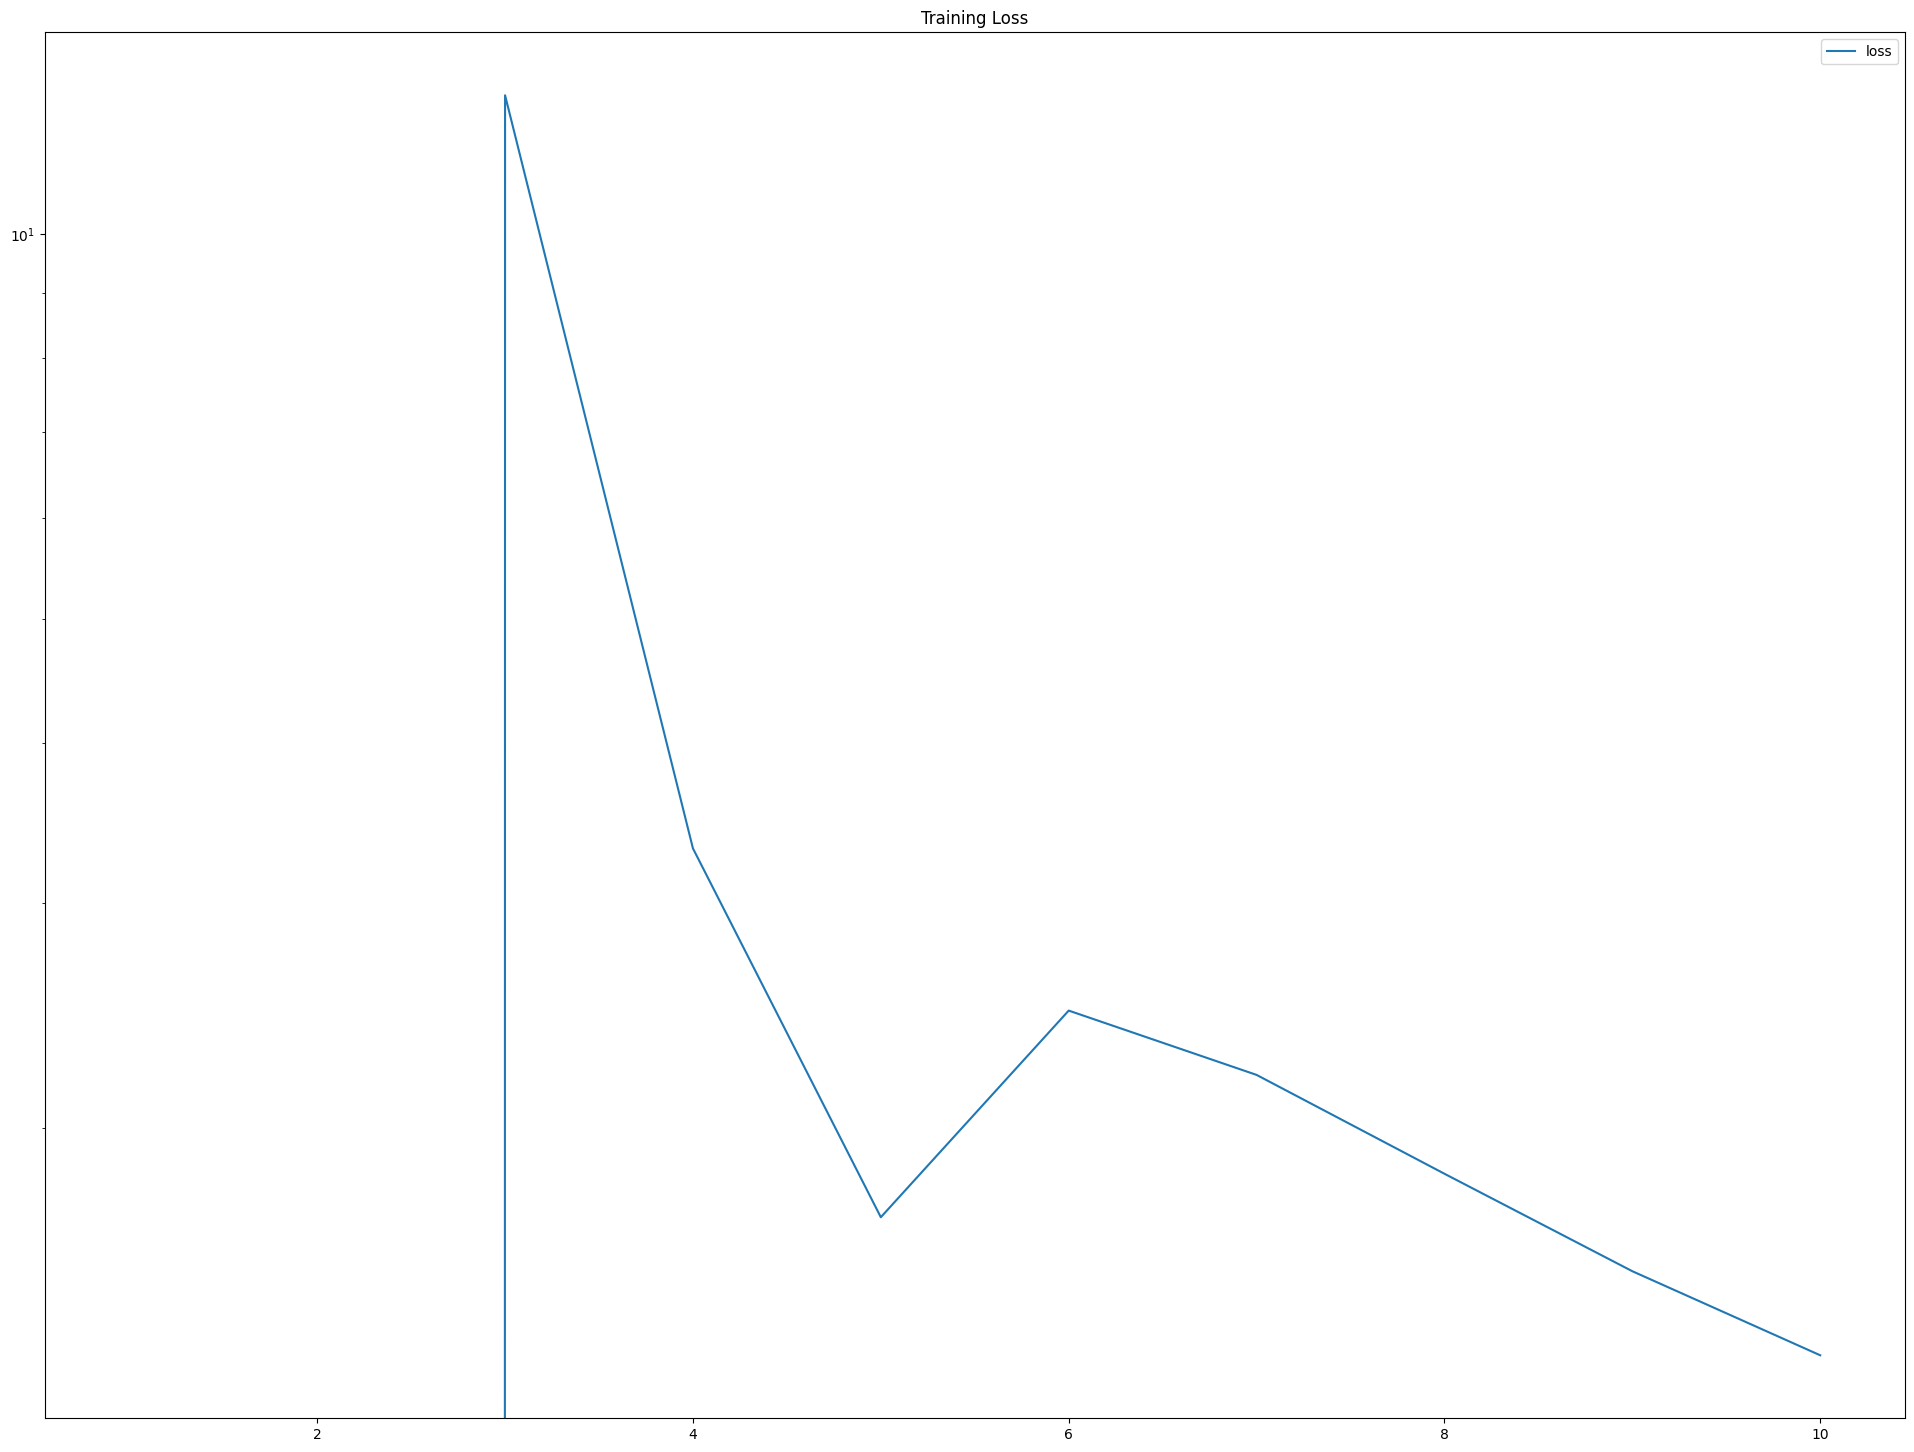

In [5]:
train = True
if train:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PitchSegmentationModel().to(device)
    print(device)

    criterion = iou_loss
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    average_loss_list = []
    scheduler = lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.01)

    epochs = 10
    model.train()
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for inputs, targets in tqdm(data_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(data_loader)
        average_loss_list.append(average_loss)
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {average_loss}')

    plt.figure()
    plt.plot(range(1, epochs+1), average_loss_list, label='loss')
    plt.yscale("log")
    plt.title("Training Loss")
    plt.legend()

    model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
    model_name = 'pitch_segmentation'
    torch.save(model.state_dict(), os.path.join(model_path, model_name))


### Inference

[  0 255]


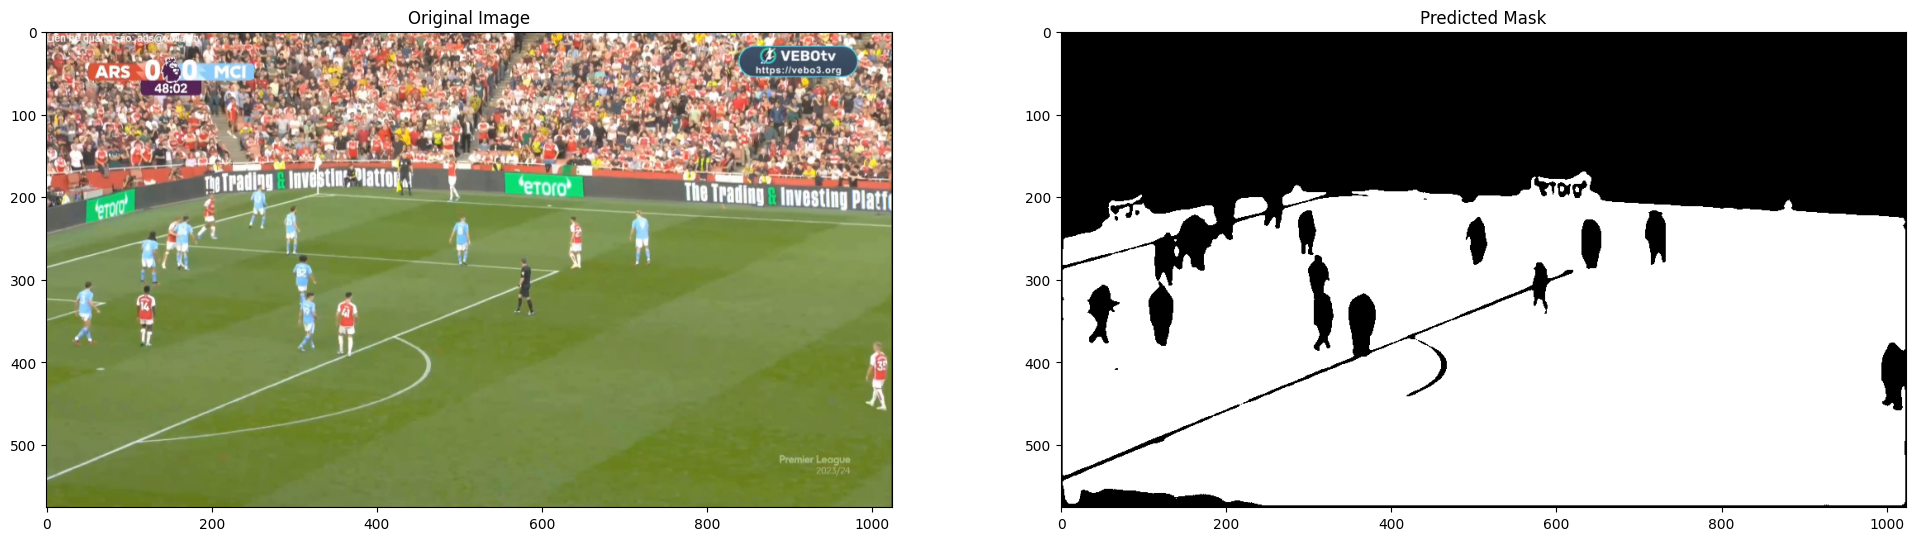

[  0 255]


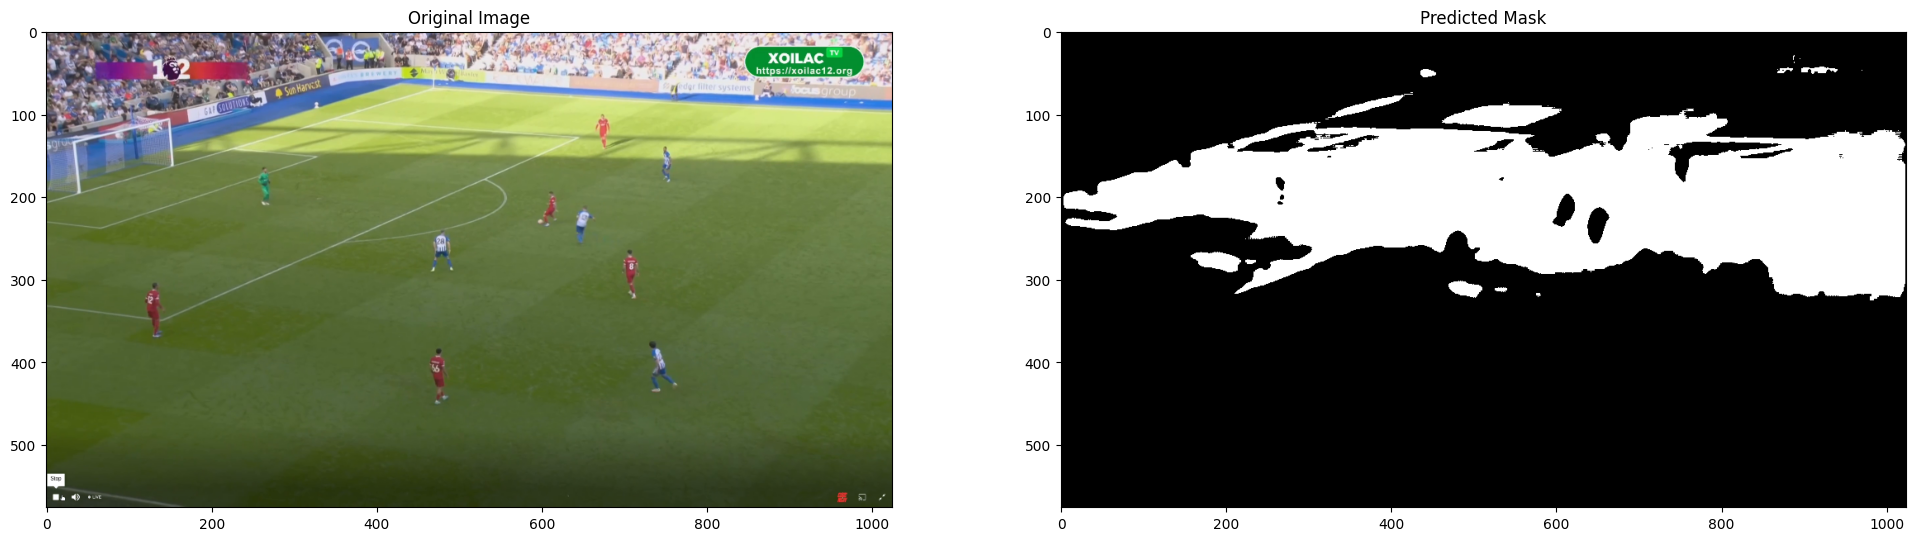

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model_name = 'pitch_segmentation'
model_path = os.path.join(model_path, model_name)

vid_name = 'real_test'
images_path = os.path.join(data_path, 'images' + '/' + vid_name)

device = "cuda" if torch.cuda.is_available() else "cpu"

for image_name in sorted(os.listdir(images_path))[:20:10]:
    image_path = os.path.join(images_path, image_name)#sorted(os.listdir(images_path))[8])
    rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)  
    pitch_segment_by_dl_model(rgb_image, model_path, visualize=True, device=device)
